In [3]:
import numpy as np
import pyccl as ccl
import healpy as hp
from tqdm import tqdm
from astropy import units as u
from matplotlib import pyplot as plt
import h5py


In [4]:
import sys, os
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/utils/')
from gaussianfield import get_cl
sys.path.append('/home/yshi/work/work_gravity/akra_series_local/core/')
from hpplot import mollview


In [5]:
### Generate gamma1, gamma2 maps from convergence map using healpy
np.random.seed(12)
nside = 1024
lmax = int(nside*2)
nside_out = nside

from akra_full import sph_kappa2gamma

l = np.arange(lmax)
cls = get_cl(ell=l)
cls[0] = 0.0
cls[1] = 0.0
### because the spin is 2, the first two multipoles are zero
alm_kappa = hp.synalm(cls)
kappa0 = hp.alm2map(alm_kappa, nside=nside_out)
gamma10, gamma20 = sph_kappa2gamma(kappa0, nside_out, lmax=lmax)

/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/pyccl/tracers.py:150: CCLWarning: The number of samples in the n(z) (200) is smaller than the number of samples in the lensing kernel (256). Consider disabling spline integration for the lensing kernel by setting pyccl.gsl_params.LENSING_KERNEL_SPLINE_INTEGRATION = False before instantiating the Cosmology passed.
  warnings.warn(
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: divide by zero encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:37: RuntimeWarning: invalid value encountered in divide
  kalmsE = alm_kappa / (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1))) ** 0.5)


/tmp/ipykernel_222086/2679846496.py:17: RuntimeWarning: invalid value encountered in divide
  Neff_pix = np.where(w2_sum > 0, w_sum**2 / w2_sum, 0)
/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/healpy/visufunc.py:356: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  pylab.draw()
/home/yshi/.conda/envs/mypy310/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


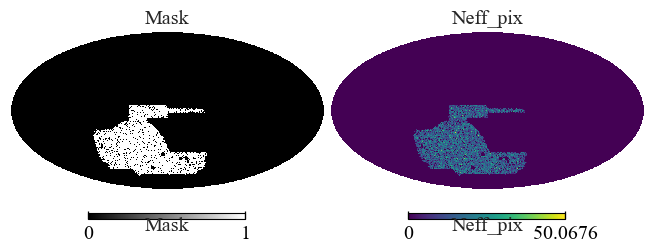

In [6]:
### mask from DESY3
#### Here you should use your own mask file, which is not provided in this repo.
skymap_dir = "/home/yshi/Data/desy3_data2/"
data_file = "desy3_shear_maps_sharp_nside2048_zmin0.0_zmax1.5.hdf5"
bin_idx = 0
neff_th = 2
nside_data = 2048

with h5py.File(skymap_dir + data_file, 'r') as f:
    grp = f[list(f.keys())[bin_idx]]
    w_sum = grp['w_sum'][:]
    w2_sum = grp['w2_sum'][:]

    pixarea = hp.nside2pixarea(nside_data, degrees=True) * u.deg**2
    pixarea_arcmin2 = pixarea.to(u.arcmin**2)

Neff_pix = np.where(w2_sum > 0, w_sum**2 / w2_sum, 0)
mask = Neff_pix > (neff_th * pixarea_arcmin2.value)
hp.mollview(mask.astype(float), title='Mask', unit='Mask', cmap='gray', sub=121)
hp.mollview(Neff_pix, title='Neff_pix', unit='Neff_pix', cmap='viridis', sub=122)

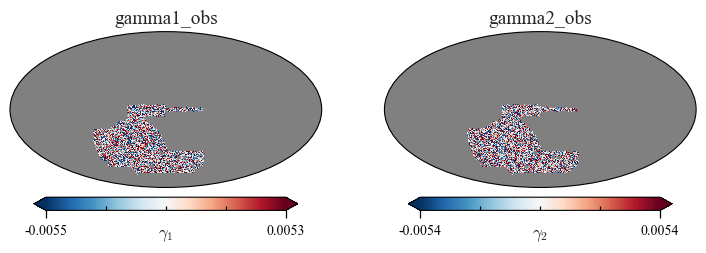

In [7]:
### Generate observed shear maps
mask = hp.ud_grade(mask.astype(float), nside_out) > 0.5
gamma1_obs = gamma10 * mask
gamma2_obs = gamma20 * mask

########## Note: Pay attention there may be -1*gamma1/gamma2 difference in different coordinate conventions ##########
########### Plot observed shear maps (gray pixels are masked)
mollview(gamma1_obs, sub=(1,2,1), title='gamma1_obs', unit="$\gamma_1$", unseen=True)
mollview(gamma2_obs, sub=(1,2,2), title='gamma2_obs', unit="$\gamma_2$", unseen=True)


## You can test AKRA 3.0 from this panel; AKRA 2.0 (direct) cannot work for Nside>256

In [8]:
from akra_full_cg import KappaRec_sphere_fast
kappa_rec = KappaRec_sphere_fast(gamma1_obs, gamma2_obs, mask, lmax=lmax)
kappa_rec.sphere_AKRA() 
akra3_map = kappa_rec.kappa_akra

/home/yshi/work/work_gravity/akra_series_local/core/akra_full_cg.py:231: RuntimeWarning: divide by zero encountered in divide
  factor = (((ell * (ell + 1.)) / ((ell + 2.) * (ell - 1.))) ** 0.5)


KappaRec_sphere_fast initialized:
  lmax = 2048
  nside = 1024
  n_cols = 4198401
  Observed yy shape: (8396802,)
  Explicit matrix would be: 564050.27 GB
Computing A^H @ y via SHT...
  Time: 1.02s
Solving (A^H A + λI) x = A^H y with matrix-free CG...
lam used without scaling:  0.001
Solving with matrix-free CG...
CG finished: 11 iterations, info=0
  Total solve time: 23.90s


## KS results

In [9]:
from akra_full import sph_gamma2kappa
ks_map, kappa_ks_B = sph_gamma2kappa(gamma1_obs, gamma2_obs, nside, lmax=lmax, return_B=True)

/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: divide by zero encountered in divide
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)
/home/yshi/work/work_gravity/akra_series_local/core/akra_full.py:56: RuntimeWarning: invalid value encountered in multiply
  alm_E = alm_E * (((ell*(ell+1.))/((ell+2.)*(ell-1)))**0.5)


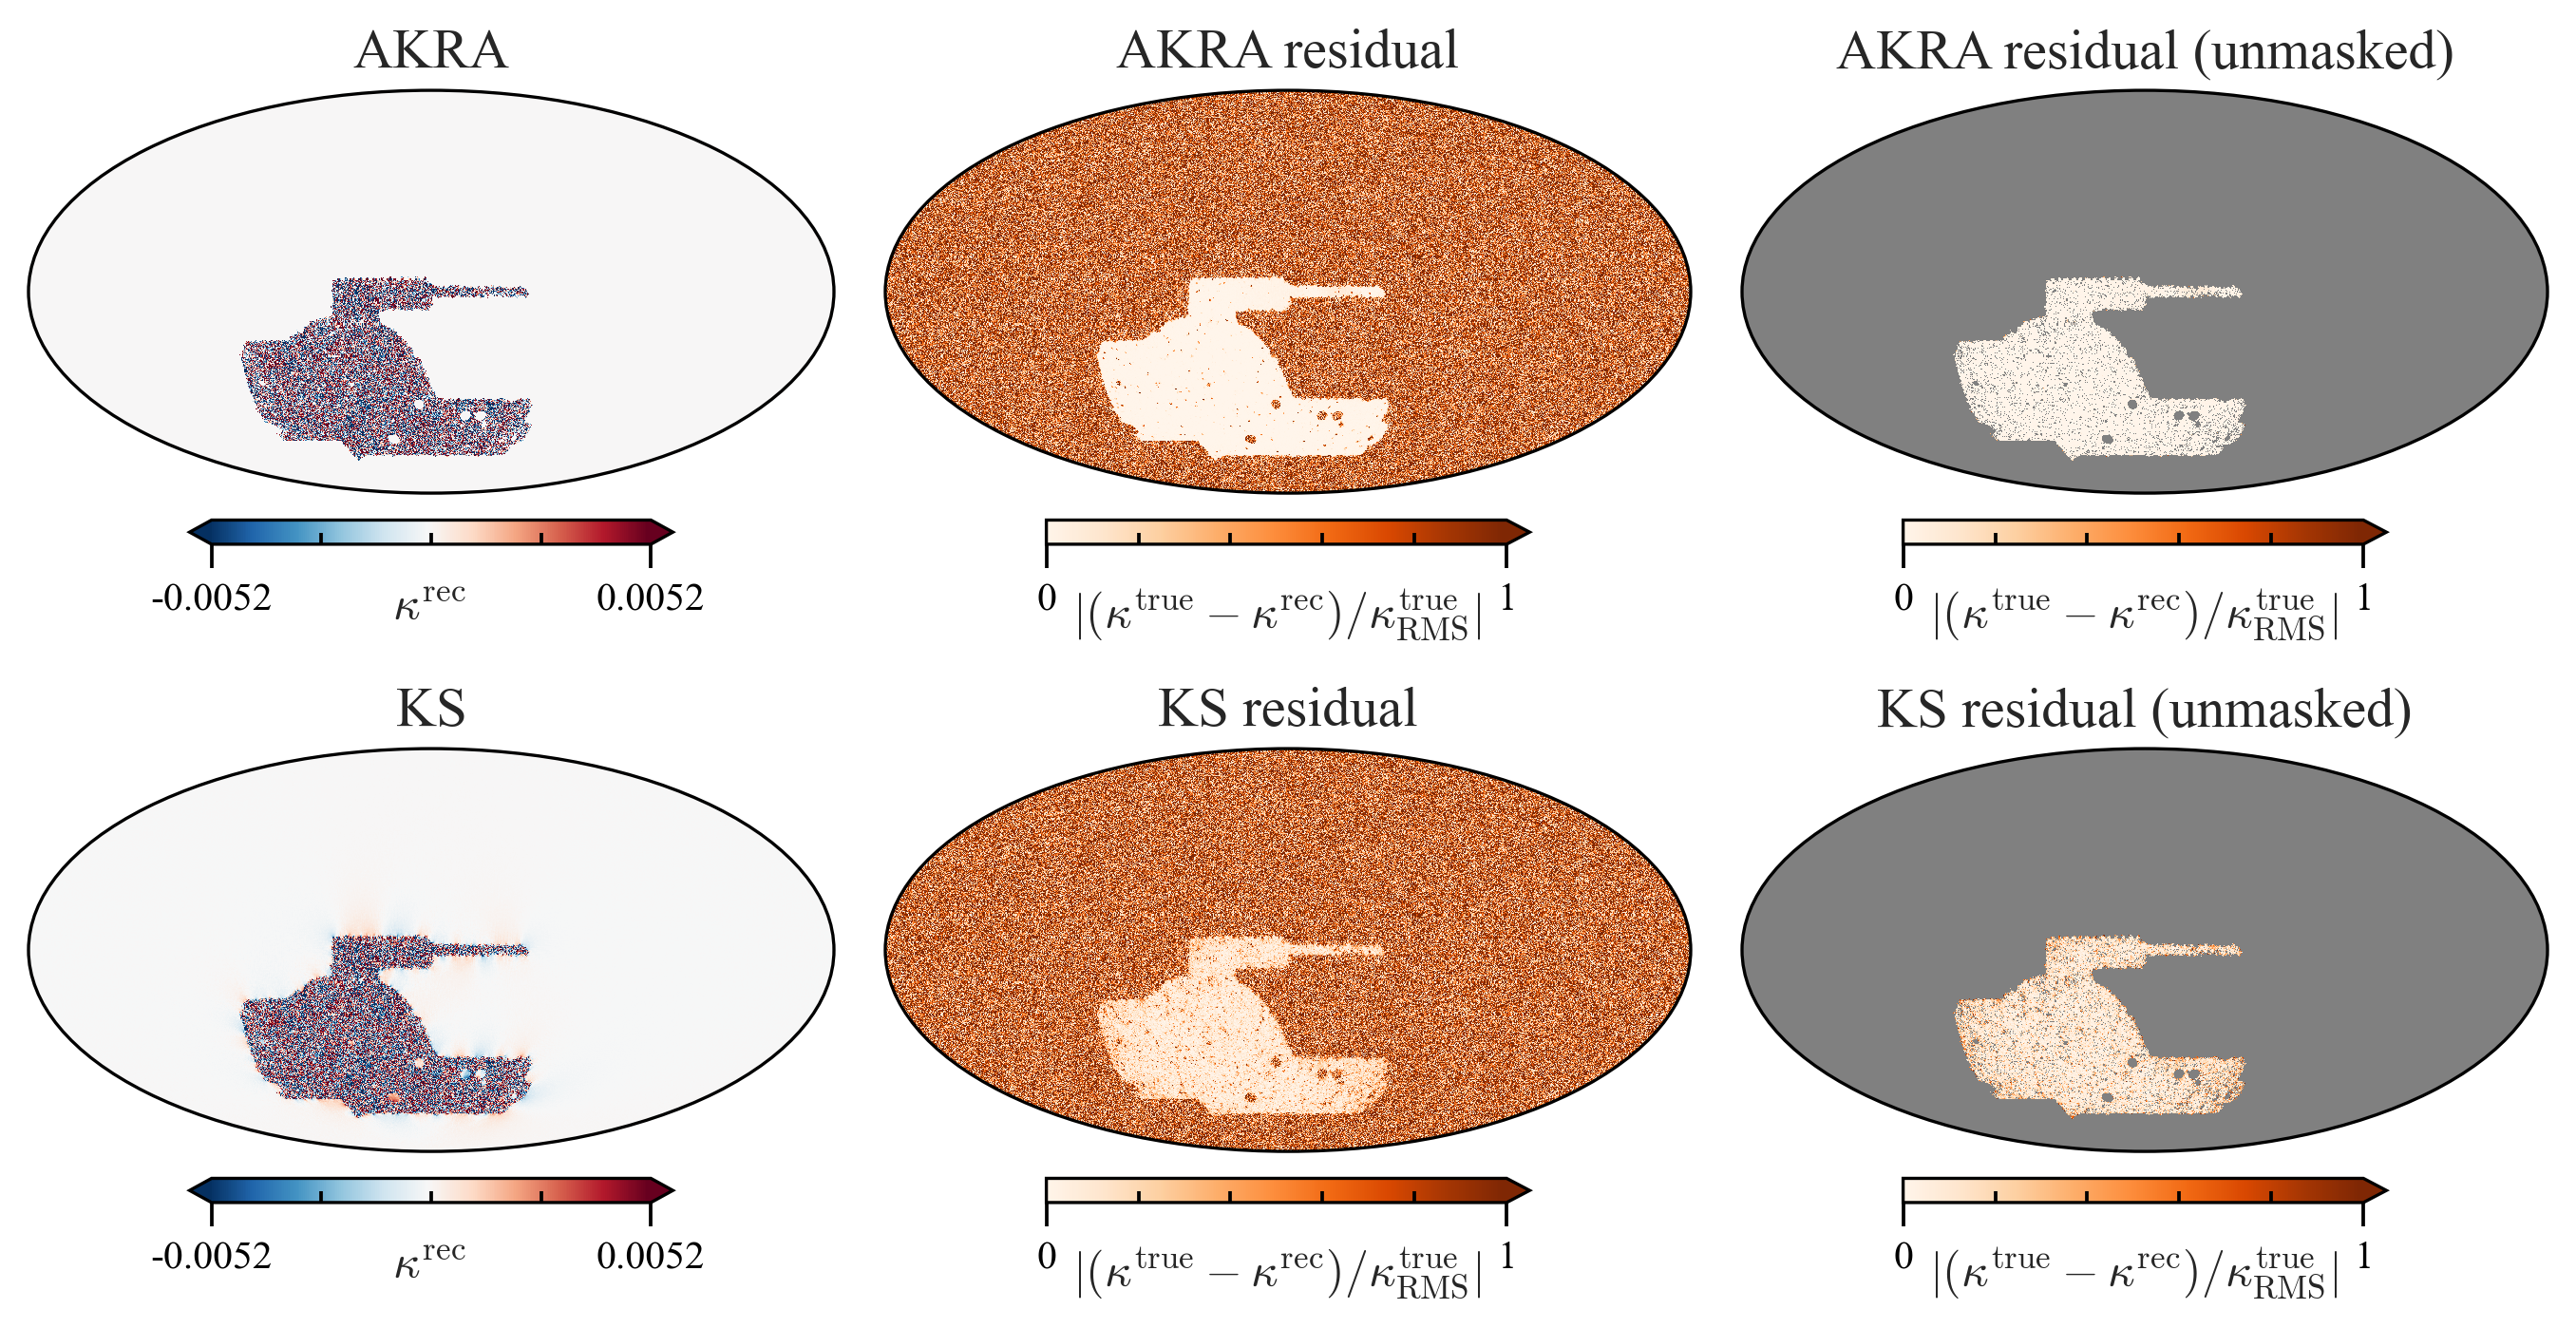

In [12]:
from hpplot import mollview

plt.figure(figsize=(9.2,4.8), dpi=300)
vmin = -0.0052
vmax = 0.0052

akra_map = akra3_map
mollview(akra_map*mask, sub=231, title="AKRA", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(akra_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=232, vmin=0, vmax=1, title="AKRA residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(akra_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=233, vmin=0, vmax=1, title="AKRA residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)

mollview(ks_map, sub=234, title="KS", unit="$\kappa^{\\rm{rec}}$ ", vmin=vmin, vmax=vmax)
mollview(np.abs(ks_map-kappa0)/np.std(kappa0), cmap="Oranges", sub=235, vmin=0, vmax=1, title="KS residual", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$")
mollview(np.abs(ks_map-kappa0)/np.std(kappa0)*mask, cmap="Oranges", sub=236, vmin=0, vmax=1, title="KS residual (unmasked)", unit="$|(\\kappa^{\\rm{true}}-\\kappa^{\\rm{rec}})/\\kappa^{\\rm{true}}_{\\rm{RMS}}|$", unseen=True)
# plt.subplots_adjust(hspace=0.01)
plt.savefig("/home/yshi/work/work_gravity/desy3_sim/kappa_rec_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()


## 1. Power-spectrum comparison

The same binary survey mask is applied to the True, KS, and AKRA maps before the spherical-harmonic transforms. Auto-spectrum ratios compare amplitude recovery, while $r_\ell$ measures phase agreement with the masked input realization.

In [9]:
alm_ks = hp.map2alm(ks_map*mask, lmax=lmax)
alm_akra = hp.map2alm(akra_map*mask, lmax=lmax)
alm_true = hp.map2alm(kappa0*mask, lmax=lmax)
ratio_ks = hp.alm2cl(alm_ks)/hp.alm2cl(alm_true)
ratio_akra = hp.alm2cl(alm_akra)/hp.alm2cl(alm_true)
rl_ks = hp.alm2cl(alm_ks, alm_true)/np.sqrt(hp.alm2cl(alm_ks)*hp.alm2cl(alm_true))
rl_akra = hp.alm2cl(alm_akra, alm_true)/np.sqrt(hp.alm2cl(alm_akra)*hp.alm2cl(alm_true))

/tmp/ipykernel_427677/395652133.py:41: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.03, wspace=0.25, left=0.085, right=0.98, top=0.96, bottom=0.13)


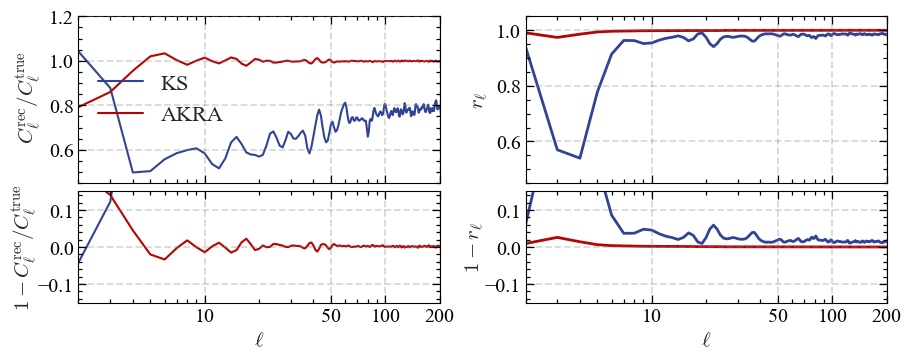

In [10]:
ell = np.arange(len(ratio_ks))
fig, axs = plt.subplots(2, 2, figsize=(9, 3.5), dpi=100, layout="constrained", sharex=True, gridspec_kw={'height_ratios': [3, 2]})
xticks = [10, 50, 100, 200]

axs[0,0].semilogx(ell, ratio_ks, label='KS', color='#314396')
axs[0,0].semilogx(ell, ratio_akra, label='AKRA', color='#B40404')
axs[0,0].set_ylim(0.45,1.2)
axs[0,0].set_ylabel(r' $ C^{\rm rec}_\ell/C^{\rm true}_\ell $', fontsize=15)
axs[0,0].legend(framealpha=0.0, fontsize=16)

axs[1,0].semilogx(ell, 1-ratio_ks, label='KS', color='#314396')
axs[1,0].semilogx(ell, 1-ratio_akra, label='AKRA', color='#B40404')
axs[1,0].set_ylim(-0.1,0.3)
axs[1,0].set_xlabel(r'$\ell$', fontsize=15)


axs[0,1].semilogx(ell, rl_ks,  color='#314396', label="KS", lw=2)
axs[0,1].semilogx(ell, rl_akra,  color="#B40404", label="AKRA", lw=2 )
axs[0,1].set_ylabel(r'$r_\ell$', fontsize=15)
axs[0,1].set_ylim(0.45,1.05)


axs[1,1].semilogx(ell, 1-rl_ks,  color='#314396', label="KS", lw=2)
axs[1,1].semilogx(ell, 1-rl_akra,  color="#B40404", label="AKRA", lw=2 )
axs[1,1].set_xlabel(r'$\ell$', fontsize=15)


for ax in axs.flat:
    ax.set_xlim(2, 200)
    ax.set_xticks(xticks)
    ax.grid(ls='--', alpha=0.3, color='gray', lw=1.3)
axs[1,0].set_ylabel(r'$ 1-C^{\rm rec}_\ell/C^{\rm true}_\ell $', fontsize=15, labelpad=-1)
axs[1,0].set_ylim(-0.15,0.15)
axs[1,0].set_yticks([-0.1, 0.0, 0.1])

axs[1,1].set_xticklabels(xticks)
axs[1,1].set_ylabel(r'$1-r_\ell$', fontsize=15, labelpad=-1)
axs[1,1].set_ylim(-0.15,0.15)
axs[1,1].set_yticks([-0.1, 0.0, 0.1])

fig.subplots_adjust(hspace=0.03, wspace=0.25, left=0.085, right=0.98, top=0.96, bottom=0.13)
plt.show()



## 2. One-point PDF comparison

The PDFs use the same finite, observed pixels for every map. Each cut-sky mean is removed because shear-only reconstruction does not constrain the convergence monopole.

True: mean= 1.222e-20, std=5.864e-03, skewness=-0.003, plotted fraction=0.99915
  KS: mean= 2.614e-20, std=5.332e-03, skewness=-0.004, plotted fraction=0.99968
AKRA: mean= 6.552e-20, std=5.858e-03, skewness=-0.003, plotted fraction=0.99916


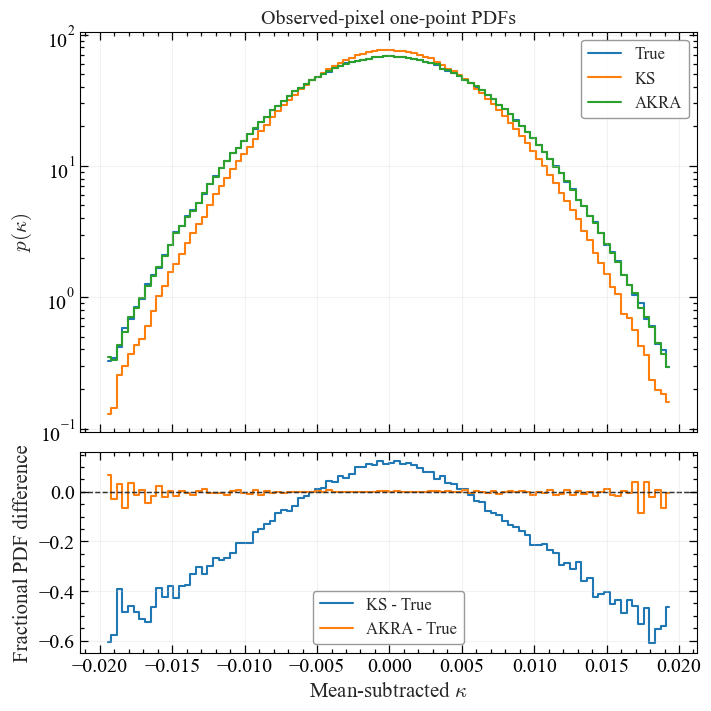

In [11]:
# Restrict all samples to a common set of valid pixels inside the survey mask.
pdf_maps = {"True": kappa0, "KS": ks_map, "AKRA": akra_map}
observed_pixels = np.asarray(mask, dtype=bool).copy()
for map_values in pdf_maps.values():
    observed_pixels &= np.isfinite(map_values) & (map_values != hp.UNSEEN)

pdf_samples = {}
for name, map_values in pdf_maps.items():
    sample = np.asarray(map_values, dtype=float)[observed_pixels].copy()
    sample -= sample.mean()
    pdf_samples[name] = sample

# Robust shared limits prevent a few extreme pixels from setting all PDF bins.
all_pdf_samples = np.concatenate(list(pdf_samples.values()))
pdf_min, pdf_max = np.percentile(all_pdf_samples, [0.1, 99.9])
pdf_padding = 0.05 * (pdf_max - pdf_min)
pdf_edges = np.linspace(pdf_min - pdf_padding, pdf_max + pdf_padding, 101)
pdf_centers = 0.5 * (pdf_edges[1:] + pdf_edges[:-1])
pdf_widths = np.diff(pdf_edges)

# Normalize by the total sample count so clipped tail probability remains visible.
pdfs = {}
for name, sample in pdf_samples.items():
    counts, _ = np.histogram(sample, bins=pdf_edges)
    pdfs[name] = counts / (sample.size * pdf_widths)
    sigma = sample.std()
    skewness = np.mean((sample / sigma) ** 3) if sigma > 0 else np.nan
    retained_fraction = counts.sum() / sample.size
    print(
        f"{name:>4s}: mean={sample.mean(): .3e}, std={sigma:.3e}, "
        f"skewness={skewness:.3f}, plotted fraction={retained_fraction:.5f}"
    )

fig, axes = plt.subplots(
    2, 1, figsize=(7, 7), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
for name, pdf_values in pdfs.items():
    axes[0].step(
        pdf_centers,
        np.where(pdf_values > 0, pdf_values, np.nan),
        where="mid",
        label=name,
    )
axes[0].set_yscale("log")
axes[0].set_ylabel(r"$p(\kappa)$")
axes[0].set_title("Observed-pixel one-point PDFs")
axes[0].legend()

valid_true_pdf = pdfs["True"] > 0
for name in ("KS", "AKRA"):
    fractional_difference = np.divide(
        pdfs[name] - pdfs["True"],
        pdfs["True"],
        out=np.full_like(pdfs[name], np.nan),
        where=valid_true_pdf,
    )
    axes[1].step(
        pdf_centers, fractional_difference, where="mid", label=f"{name} - True"
    )
axes[1].axhline(0.0, color="k", ls="--", lw=1)
axes[1].set_xlabel(r"Mean-subtracted $\kappa$")
axes[1].set_ylabel("Fractional PDF difference")
axes[1].legend()

for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

## 3. NaMaster-deconvolved power spectra

The True spectrum is measured from the unmasked full-sky convergence map. KS and AKRA use the same binary survey mask and one shared NaMaster workspace. The figure compares the full-sky True spectrum with the two deconvolved reconstruction spectra.

<>:39: SyntaxWarning: invalid escape sequence '\k'
<>:39: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_427677/2762016851.py:39: SyntaxWarning: invalid escape sequence '\k'
  plt.title("Deconvolved auto-spectra of $\kappa^{\\rm{rec}}$")


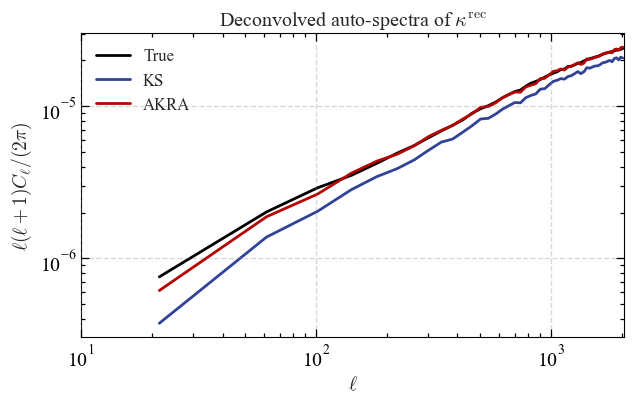

In [12]:
import pymaster as nmt

nmt_lmax = min(int(lmax), 2 * hp.get_nside(kappa0) - 1)
bin_width = 40
bins = nmt.NmtBin.from_lmax_linear(lmax=nmt_lmax, nlb=bin_width)
ell_eff = bins.get_effective_ells()

# Full-sky True spectrum: no survey mask is applied.
alm_true = hp.map2alm(kappa0, lmax=nmt_lmax)
cl_true = hp.alm2cl(alm_true)
cl_true_binned = bins.bin_cell(np.asarray([cl_true]))[0]

# KS and AKRA use exactly the same binary survey mask.
binary_mask = np.asarray(mask, dtype=float)
field_ks = nmt.NmtField(binary_mask, [ks_map], lmax=nmt_lmax)
field_akra = nmt.NmtField(binary_mask, [akra_map], lmax=nmt_lmax)

# One workspace is sufficient because both reconstructions use the same mask.
workspace = nmt.NmtWorkspace()
workspace.compute_coupling_matrix(field_ks, field_ks, bins)

def deconvolved_auto_spectrum(field):
    coupled_cl = nmt.compute_coupled_cell(field, field)
    return workspace.decouple_cell(coupled_cl)[0]

cl_ks_deconvolved = deconvolved_auto_spectrum(field_ks)
cl_akra_deconvolved = deconvolved_auto_spectrum(field_akra)

factor = ell_eff * (ell_eff + 1) / (2 * np.pi)
plt.figure(figsize=(6.5, 4.2), dpi=100)
plt.loglog(ell_eff, factor * cl_true_binned, color="k", lw=2, label="True")
plt.loglog(ell_eff, factor * cl_ks_deconvolved, color="#314396", lw=2, label="KS")
plt.loglog(ell_eff, factor * cl_akra_deconvolved, color="#B40404", lw=2, label="AKRA")
plt.xlabel(r"$\ell$", fontsize=14)
plt.ylabel(r"$\ell(\ell+1)C_\ell/(2\pi)$", fontsize=14)
plt.xlim(10,np.max(nmt_lmax))
plt.grid(ls="--", alpha=0.3, color="gray", lw=1.0)
plt.legend(framealpha=0.0, fontsize=12)
plt.title("Deconvolved auto-spectra of $\kappa^{\\rm{rec}}$")
plt.tight_layout()
plt.show()